In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from datetime import timedelta

In [2]:
# Load data from Task 2
df = pd.read_csv("processed_aapl_data.csv", parse_dates=['Date'])
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df = df[:-1]

In [3]:
# Features used
features = ['SMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_Signal','Daily_Return']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

X = df[features]
y = df['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Generate predictions for backtesting
df['Predicted_Signal'] = 0
df.iloc[len(X_train):, df.columns.get_loc('Predicted_Signal')] = model.predict(X_test)

In [5]:
df['Strategy_Return'] = 0.0
df['Market_Return'] = df['Close'].pct_change()


In [7]:
# Apply strategy: if predicted 1 → take position
df['Position'] = df['Predicted_Signal'].shift(1)
df['Position'] = df['Position'].fillna(0)

In [8]:
# Calculate strategy returns
df['Strategy_Return'] = df['Market_Return'] * df['Position']

In [9]:
# Apply transaction cost on trades
df['Trade'] = df['Position'].diff().abs()  # 1 if position changes
transaction_cost = 0.001  # 0.1% per trade
df['Strategy_Return'] -= df['Trade'] * transaction_cost

In [10]:
# Cumulative returns
df['Cumulative_Strategy'] = (1 + df['Strategy_Return']).cumprod()
df['Cumulative_Market'] = (1 + df['Market_Return']).cumprod()

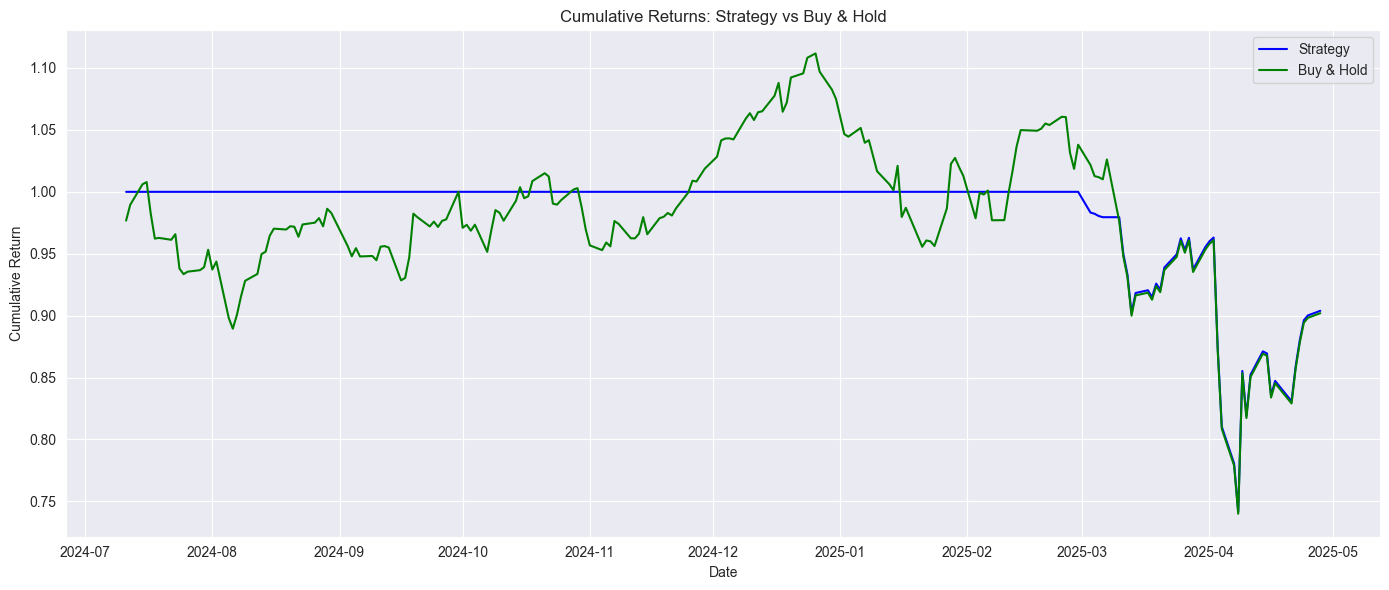

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative_Strategy'], label='Strategy', color='blue')
plt.plot(df['Date'], df['Cumulative_Market'], label='Buy & Hold', color='green')
plt.title("Cumulative Returns: Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
def sharpe_ratio(returns, risk_free_rate=0.0):
    excess_return = returns - risk_free_rate / 252
    return np.mean(excess_return) / (np.std(excess_return) + 1e-9) * np.sqrt(252)

def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

strategy_sharpe = sharpe_ratio(df['Strategy_Return'].dropna())
market_sharpe = sharpe_ratio(df['Market_Return'].dropna())

strategy_mdd = max_drawdown(df['Cumulative_Strategy'])
market_mdd = max_drawdown(df['Cumulative_Market'])
final_strategy_return = df['Cumulative_Strategy'].iloc[-1] - 1
final_market_return = df['Cumulative_Market'].iloc[-1] - 1

print("\nStrategy Performance Metrics:")
print(f"Cumulative Return      : {final_strategy_return:.2%}")
print(f"Sharpe Ratio           : {strategy_sharpe:.2f}")
print(f"Maximum Drawdown       : {strategy_mdd:.2%}")

print("\nBuy & Hold Metrics:")
print(f"Cumulative Return      : {final_market_return:.2%}")
print(f"Sharpe Ratio           : {market_sharpe:.2f}")
print(f"Maximum Drawdown       : {market_mdd:.2%}")


Strategy Performance Metrics:
Cumulative Return      : -9.61%
Sharpe Ratio           : -0.36
Maximum Drawdown       : -25.83%

Buy & Hold Metrics:
Cumulative Return      : -9.80%
Sharpe Ratio           : -0.22
Maximum Drawdown       : -33.43%


1.Parameter Optimization using Grid Search (for XGBoost)

In [14]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [15]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

In [16]:
grid_search = GridSearchCV(estimator=XGBClassifier(eval_metric='logloss', random_state=42),param_grid=param_grid,scoring='accuracy',cv=3,n_jobs=-1,verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 6, 9], 'n_estimators': [50, 100, 150],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy', verbose=1)

In [17]:
print("Best Parameters from Grid Search:", grid_search.best_params_)

Best Parameters from Grid Search: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}


In [18]:
best_model = grid_search.best_estimator_

In [19]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.15      0.26        20
           1       0.55      1.00      0.71        21

    accuracy                           0.59        41
   macro avg       0.78      0.57      0.49        41
weighted avg       0.77      0.59      0.49        41



2.Strategy Refinement: Risk Management

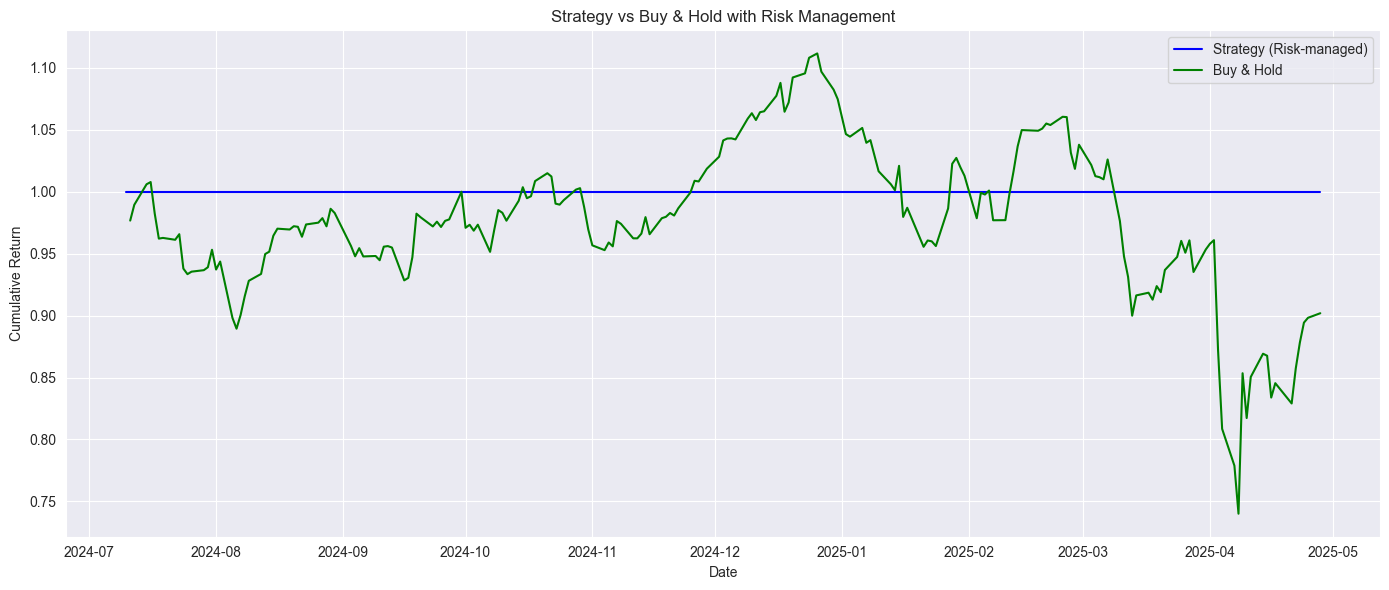

In [22]:
# Define Stop-Loss and Take-Profit thresholds
stop_loss_pct = 0.02  # 2% stop-loss
take_profit_pct = 0.03  # 3% take-profit

# Backtest with risk management
# Backtest with risk management
df['Entry_Price'] = np.nan
df['Exit_Price'] = np.nan
df['Trade_Executed'] = False
df['Strategy_Return'] = 0.0

# Iterate through data and execute strategy
for i in range(1, len(df)):
    if df['Predicted_Signal'].iloc[i] == 1 and not df['Trade_Executed'].iloc[i-1]:
        df.loc[i, 'Entry_Price'] = df['Close'].iloc[i]  # Use .loc instead of .iloc
        df.loc[i, 'Trade_Executed'] = True  # Use .loc instead of .iloc

    # Check if stop-loss or take-profit is triggered
    if df['Trade_Executed'].iloc[i]:
        entry_price = df['Entry_Price'].iloc[i]
        stop_loss = entry_price * (1 - stop_loss_pct)
        take_profit = entry_price * (1 + take_profit_pct)

        if df['Close'].iloc[i] <= stop_loss:
            df.loc[i, 'Exit_Price'] = stop_loss  # Use .loc instead of .iloc
            df.loc[i, 'Trade_Executed'] = False  # Use .loc instead of .iloc
            df.loc[i, 'Strategy_Return'] = -stop_loss_pct  # Use .loc instead of .iloc

        elif df['Close'].iloc[i] >= take_profit:
            df.loc[i, 'Exit_Price'] = take_profit  # Use .loc instead of .iloc
            df.loc[i, 'Trade_Executed'] = False  # Use .loc instead of .iloc
            df.loc[i, 'Strategy_Return'] = take_profit_pct  # Use .loc instead of .iloc


# Recalculate cumulative returns with risk management
df['Cumulative_Strategy'] = (1 + df['Strategy_Return']).cumprod()
df['Cumulative_Market'] = (1 + df['Market_Return']).cumprod()

# Plot strategy performance
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative_Strategy'], label='Strategy (Risk-managed)', color='blue')
plt.plot(df['Date'], df['Cumulative_Market'], label='Buy & Hold', color='green')
plt.title("Strategy vs Buy & Hold with Risk Management")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3.Performance Evaluation

In [24]:
# Recalculate the Sharpe Ratio and Max Drawdown with risk management
strategy_sharpe_optimized = sharpe_ratio(df['Strategy_Return'].dropna())
market_sharpe_optimized = sharpe_ratio(df['Market_Return'].dropna())

strategy_mdd_optimized = max_drawdown(df['Cumulative_Strategy'])
market_mdd_optimized = max_drawdown(df['Cumulative_Market'])

final_strategy_return_optimized = df['Cumulative_Strategy'].iloc[-1] - 1
final_market_return_optimized = df['Cumulative_Market'].iloc[-1] - 1

print("\nOptimized Strategy Performance Metrics:")
print(f"Cumulative Return      : {final_strategy_return_optimized:.2%}")
print(f"Sharpe Ratio           : {strategy_sharpe_optimized:.2f}")
print(f"Maximum Drawdown       : {strategy_mdd_optimized:.2%}")

print("\nOptimized Buy & Hold Metrics:")
print(f"Cumulative Return      : {final_market_return_optimized:.2%}")
print(f"Sharpe Ratio           : {market_sharpe_optimized:.2f}")
print(f"Maximum Drawdown       : {market_mdd_optimized:.2%}")



Optimized Strategy Performance Metrics:
Cumulative Return      : 0.00%
Sharpe Ratio           : 0.00
Maximum Drawdown       : 0.00%

Optimized Buy & Hold Metrics:
Cumulative Return      : -9.80%
Sharpe Ratio           : -0.22
Maximum Drawdown       : -33.43%
